# Multiple Linear Regression - House Price Dataset

**Goal:** predict `Price_Lakh` from 4 independent features.

| Feature | Meaning |
|---|---|
| House_Size_sqft | Size of the house in square feet |
| Bedrooms | Number of bedrooms |
| House_Age_years | Age of the house in years |
| Distance_to_City_km | Distance from the city centre |
| **Price_Lakh** | **Target / dependent feature** |

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [116]:
df=pd.read_csv("house_price_multiple_regression_100.csv")
df.head()

,House_Size_sqft,Bedrooms,House_Age_years,Distance_to_City_km,Price_Lakh
0,1959,3,23,6.8,105.8
1,2035,4,17,2.8,133.9
2,1514,2,2,5.6,91.0
3,1057,2,22,12.4,46.1
4,1101,2,8,18.0,66.1


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_Size_sqft      100 non-null    int64  
 1   Bedrooms             100 non-null    int64  
 2   House_Age_years      100 non-null    int64  
 3   Distance_to_City_km  100 non-null    float64
 4   Price_Lakh           100 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 4.0 KB


In [118]:
## check null values
df.isnull().sum()

House_Size_sqft        0
Bedrooms               0
House_Age_years        0
Distance_to_City_km    0
Price_Lakh             0
dtype: int64

In [119]:
# Summary Stats
df.describe()

,House_Size_sqft,Bedrooms,House_Age_years,Distance_to_City_km,Price_Lakh
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1615.150000,3.000000,14.410000,11.444000,88.046000
std,572.508839,1.110101,9.096669,5.761617,37.683805
min,650.000000,1.000000,0.000000,1.100000,18.000000
25%,1099.500000,2.000000,7.000000,6.750000,57.100000
50%,1680.000000,3.000000,14.000000,10.650000,89.000000
75%,2060.500000,4.000000,21.250000,16.600000,119.125000
max,2578.000000,5.000000,30.000000,21.700000,172.100000


# Visualization

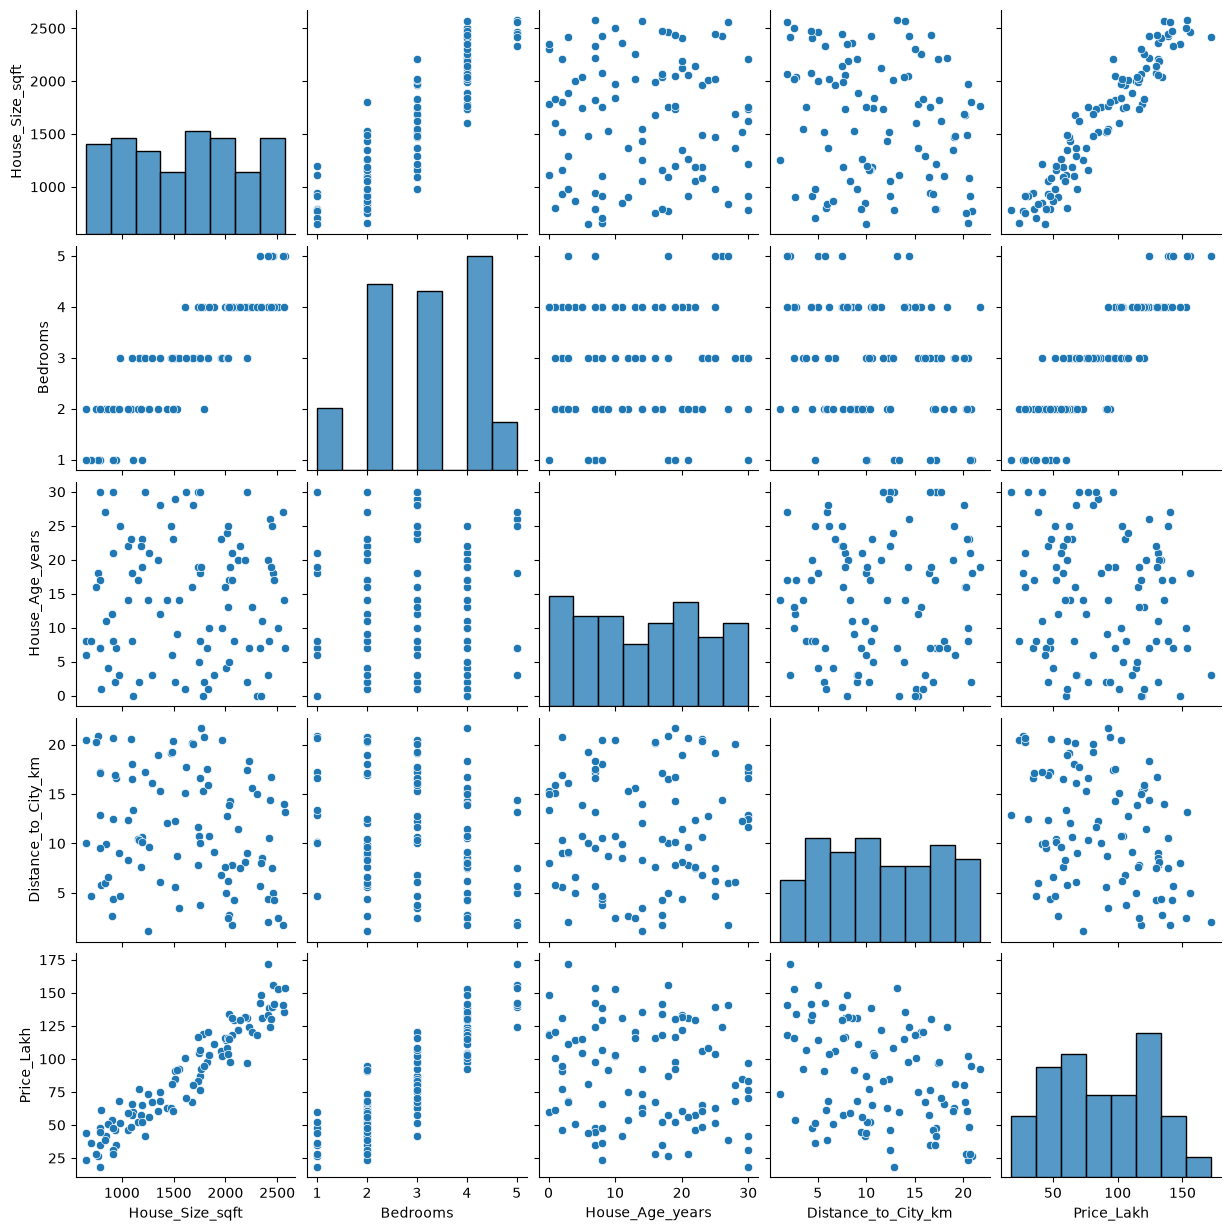

In [120]:
sns.pairplot(df)

In [121]:
# Correlation
df.corr()

,House_Size_sqft,Bedrooms,House_Age_years,Distance_to_City_km,Price_Lakh
House_Size_sqft,1.000000,0.876560,0.016594,-0.210796,0.950673
Bedrooms,0.876560,1.000000,0.009002,-0.254579,0.884014
House_Age_years,0.016594,0.009002,1.000000,0.064678,-0.167042
Distance_to_City_km,-0.210796,-0.254579,0.064678,1.000000,-0.360904
Price_Lakh,0.950673,0.884014,-0.167042,-0.360904,1.000000


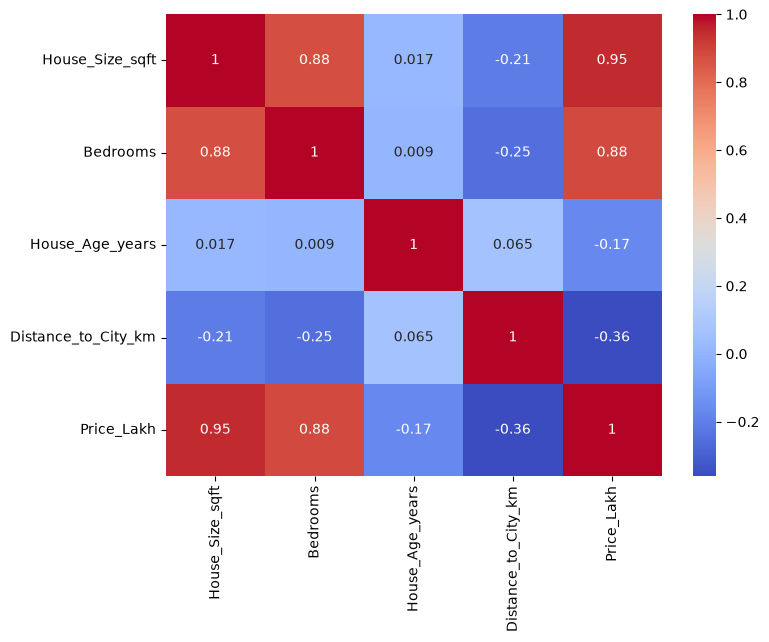

In [122]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

Text(0, 0.5, 'Price (Lakh)')

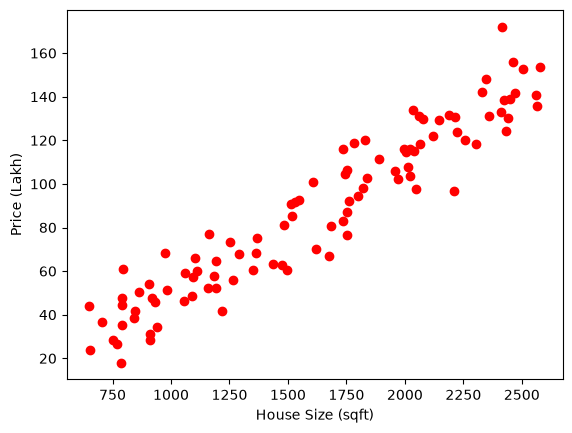

In [123]:
## Visualize the datapoints more closely
plt.scatter(df['House_Size_sqft'],df['Price_Lakh'],color='r')
plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakh)")

### What is `regplot`?

`sns.regplot(x=..., y=...)` = **scatter plot + best fit line, in one call**.

It draws three things:

| What you see | What it means |
|---|---|
| The dots | The actual data points (same as `plt.scatter`) |
| The straight line | The least-squares regression line seaborn fits for you |
| The shaded band | 95% confidence interval - how sure we are about the line's position |

**Why it is useful:**

1. **Direction** - is the line sloping up (positive) or down (negative)?
2. **Strength** - are the dots hugging the line, or scattered far from it?
3. **Linearity check** - linear regression assumes a *straight line* relationship.
   If the dots form a curve, the straight line will fit badly and you know
   you need a transformation (log, polynomial features, etc.)
4. **Outliers** - points sitting far away from everything else are easy to spot.
5. **Confidence** - a wide shaded band means "not much data here, do not trust
   this part of the line".

It is a **quick visual sanity check before modelling** - it does not replace the
model, it just tells you whether a linear model is a reasonable idea at all.

> **Important:** `regplot` shows only **one feature at a time**, ignoring the
> other columns. A feature can look weak here but still be very useful in the
> full multiple regression, because the model looks at all features *together*.
> Watch this happen with `House_Age_years` below.

<Axes: xlabel='House_Size_sqft', ylabel='Price_Lakh'>

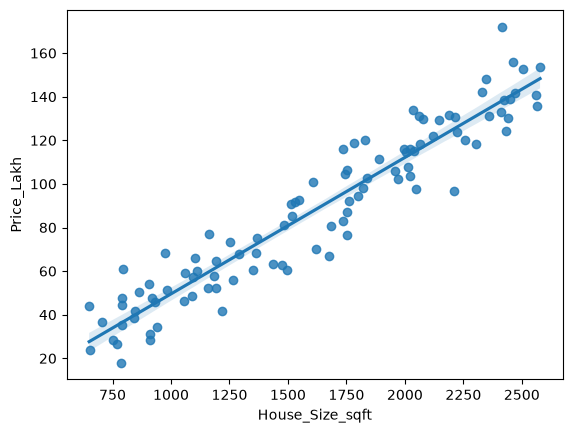

In [124]:
sns.regplot(x=df["House_Size_sqft"], y=df["Price_Lakh"])

<Axes: xlabel='Bedrooms', ylabel='Price_Lakh'>

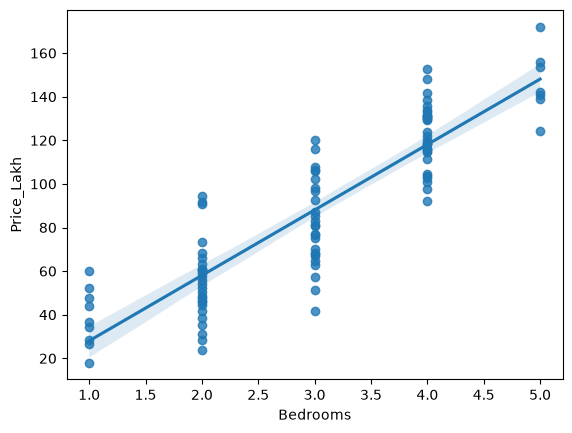

In [125]:
sns.regplot(x=df["Bedrooms"], y=df["Price_Lakh"])

<Axes: xlabel='House_Age_years', ylabel='Price_Lakh'>

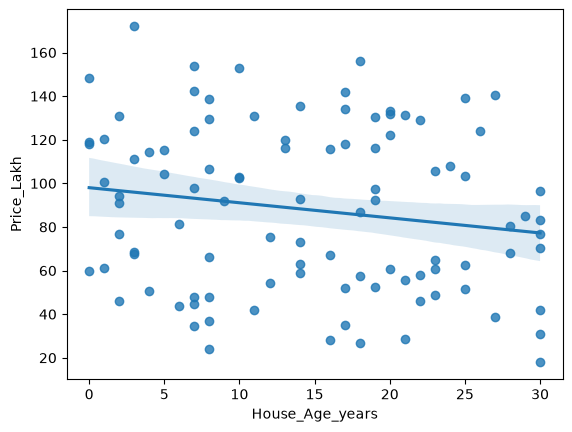

In [126]:
## Line slopes down (older = cheaper) but the dots are spread out widely,
## so on its own this looks like a weak feature.
## It is NOT weak - the spread is caused by house size, which regplot ignores.
## Once size is accounted for, age becomes one of the strongest predictors.
sns.regplot(x=df['House_Age_years'],y=df['Price_Lakh'])

## 3. Independent and dependent features

In [127]:
X = df.iloc[:, :-1] # All rows, all columns except last one 
y = df.iloc[:, -1]

In [128]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=45)


In [129]:
print(X_train.shape)
print(X_test.shape)

(75, 4)
(25, 4)


In [130]:
# Standarize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [131]:
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)
X_train

array([[-1.15077784, -1.84834844, -0.75327561,  0.92103839],
       [ 1.03448777,  0.90581314,  0.62985757, -0.66460021],
       [-1.16657494, -0.93029458, -1.28524991,  0.97700211],
       [ 0.15336059, -0.01224072,  1.48101645,  1.5739484 ],
       [-0.28018206, -0.93029458, -0.00851159,  0.08158266],
       [-1.663306  , -1.84834844, -0.85967047, -0.31016335],
       [ 0.40786944, -0.01224072, -1.39164477,  0.79045639],
       [ 1.07661338, -0.01224072,  1.69380617,  1.07027496],
       [-1.29119651, -0.93029458, -1.07246019, -0.94441879],
       [ 0.84492256,  0.90581314, -0.64688075, -1.37347394],
       [-1.0910999 , -0.93029458, -1.17885505, -0.49670906],
       [ 1.46451996,  1.82386701,  1.26822673,  0.51063781],
       [-1.31576978, -0.93029458, -0.32769617, -0.32881792],
       [ 0.269206  , -0.01224072, -0.64688075, -1.4667468 ],
       [ 1.23633962,  0.90581314, -1.49803963,  0.62256524],
       [ 0.01469715,  0.90581314, -1.39164477,  0.64121981],
       [-0.20295179, -0.

In [132]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [133]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[28.72, 6.97,-6.42,-5.3 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,86.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[12.09, 8.98, 8.04, 2.93]"


In [134]:
## Cross Validation
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error", cv=5)
validation_score

array([-78.18337741, -48.54591255, -24.50577452, -36.55527306,
       -88.72056694])

In [135]:
np.mean(validation_score)

np.float64(-55.30218089532203)

In [136]:
print(f"Intercept = {regression.intercept_}")
for col_name,coef in zip(X.columns,regression.coef_):
    print(f"{col_name} : {coef}")

Intercept = 86.88533333333334
House_Size_sqft : 28.717198367368404
Bedrooms : 6.973335800157589
House_Age_years : -6.418366135482556
Distance_to_City_km : -5.300331928400851


In [137]:
y_pred = regression.predict(X_test)
y_pred

array([103.7318194 , 122.01683053, 139.75668689, 149.04149882,
        92.37361964,  71.03639882, 127.37197136,  57.31433955,
        90.42653414, 147.24974179,  58.15762487,  73.42473754,
        56.81856938,  32.36954871,  28.24817691,  53.25127019,
       118.03821895,  61.2632166 ,  32.74799247, 124.51774634,
        65.75776771, 147.13409331,  93.59870212, 115.65048312,
        89.71259967])

In [138]:
# Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MSE :",mse)
print("MAE :",mae)
print("RMSE:",rmse)

MSE : 38.38258149795482
MAE : 4.785776507474027
RMSE: 6.195367745175004


In [139]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2         :",score)
print("Adjusted R2:",1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

R2         : 0.9705923601151398
Adjusted R2: 0.9647108321381678


Text(0, 0.5, 'Predicted Price')

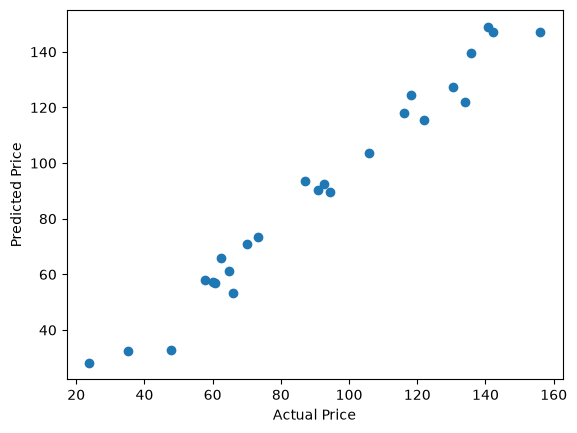

In [140]:
# Actual vs Predicted scatter
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

In [141]:
residuals=y_test-y_pred
residuals

0      2.068181
1     11.883169
62    -4.056687
76    -8.341499
37     0.226380
99    -0.836399
78     3.028029
38     2.685660
2      0.573466
84    -4.949742
60    -0.257625
26    -0.224738
69     3.781431
33     2.830451
51    -4.448177
4     12.848730
92    -1.938219
7      3.536783
10    15.052008
74    -6.417746
45    -3.157768
9      8.865907
20    -6.598702
18     6.449517
73     4.587400
Name: Price_Lakh, dtype: float64

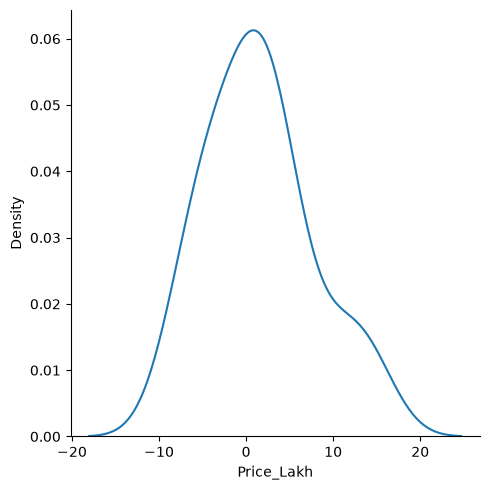

In [142]:
## Plot the residuals
sns.displot(residuals,kind='kde')

Text(0, 0.5, 'Residuals')

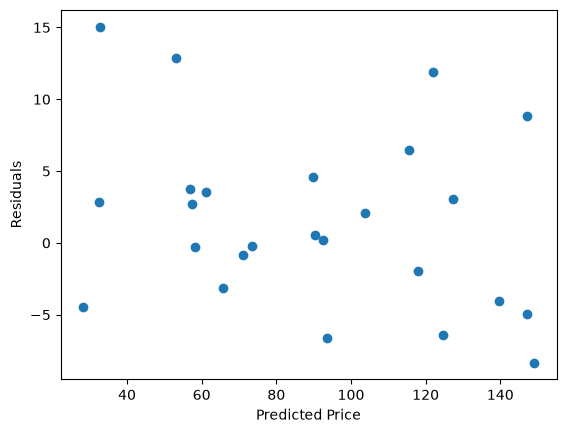

In [143]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

In [144]:
import statsmodels.api as sm
model=sm.OLS(y_train,sm.add_constant(X_train)).fit()

In [145]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Price_Lakh   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     485.3
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           3.16e-50
Time:                        22:05:32   Log-Likelihood:                -253.06
No. Observations:                  75   AIC:                             516.1
Df Residuals:                      70   BIC:                             527.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.8853      0.844    102.890      0.0

In [150]:
# Preditiction
new_data=pd.DataFrame([[2000,5,10,7.6]],columns=X.columns)
regression.predict(scaler.transform(new_data))

array([126.68868776])